# Tehran Rental Market - Cleaning, EDA & Modelling Walkthrough
The reusable code lives in `src/rental`; this notebook tells the story. Run `make data && make train` first.

In [1]:
import sys; sys.path.insert(0, '../src')
import json, pandas as pd, numpy as np
from IPython.display import Image
from rental.data import load_raw, clean
pd.set_option('display.max_columns', 30); pd.set_option('display.float_format', '{:,.1f}'.format)
raw = load_raw(); raw.head()

,total_value,neighborhood,area,year,deposit,rent,elavator,parking,warehouse
0,"2,000,900,000.0",ولنجک,270,1399,"2,000,000,000.0","30,000,000.0",1,1,1
1,"200,120,000.0",کوی فردوس,70,1387,"200,000,000.0","4,000,000.0",0,1,1
2,"350,255,000.0",پونک,120,1395,"350,000,000.0","8,500,000.0",1,1,1
3,"200,300,000.0",هروی,110,1395,"200,000,000.0","10,000,000.0",1,1,1
4,"200,180,000.0",پونک,80,1387,"200,000,000.0","6,000,000.0",1,1,1


## 1. Data quality audit
The raw file has obvious problems: 12% of rows have no price at all, some areas are 300,000 m², some rents are 35 billion Toman, and 98 listings share the exact rent `100,000` (a placeholder). Every removal is a documented rule so the cleaning is auditable.

In [2]:
raw.describe(percentiles=[.01, .5, .99]).T

,count,mean,std,min,1%,50%,99%,max
total_value,"12,383.0","495,842,144.8","885,827,628.0",0.0,0.0,"300,000,000.0","3,500,000,000.0","50,000,135,000.0"
area,"12,383.0",171.5,"2,979.6",5.0,45.0,115.0,370.0,"300,000.0"
year,"12,383.0","1,391.7",6.7,"1,363.0","1,371.0","1,393.0","1,399.0","1,399.0"
deposit,"12,383.0","495,288,202.6","885,692,488.6",0.0,0.0,"300,000,000.0","3,500,000,000.0","50,000,000,000.0"
rent,"12,383.0","18,464,740.1","477,377,367.3",0.0,0.0,"1,500,000.0","60,000,000.0","35,000,000,000.0"
elavator,"12,383.0",0.8,0.4,0.0,0.0,1.0,1.0,1.0
parking,"12,383.0",0.9,0.3,0.0,0.0,1.0,1.0,1.0
warehouse,"12,383.0",1.0,0.0,0.0,1.0,1.0,1.0,1.0


In [3]:
df, rep = clean(raw, return_report=True)
rep

,rule,removed,remaining
0,raw rows,0,12383
1,no price (deposit = 0 and rent = 0),1536,10847
2,area outside 20-600 m2,14,10833
3,"monthly rent > 300,000,000 Toman (typo)",16,10817
4,"0 < rent < 500,000 Toman (placeholder / unit e...",166,10651
5,build year < 1350,0,10651
6,value/m2 outside 0.5%-99.5% quantiles,107,10544


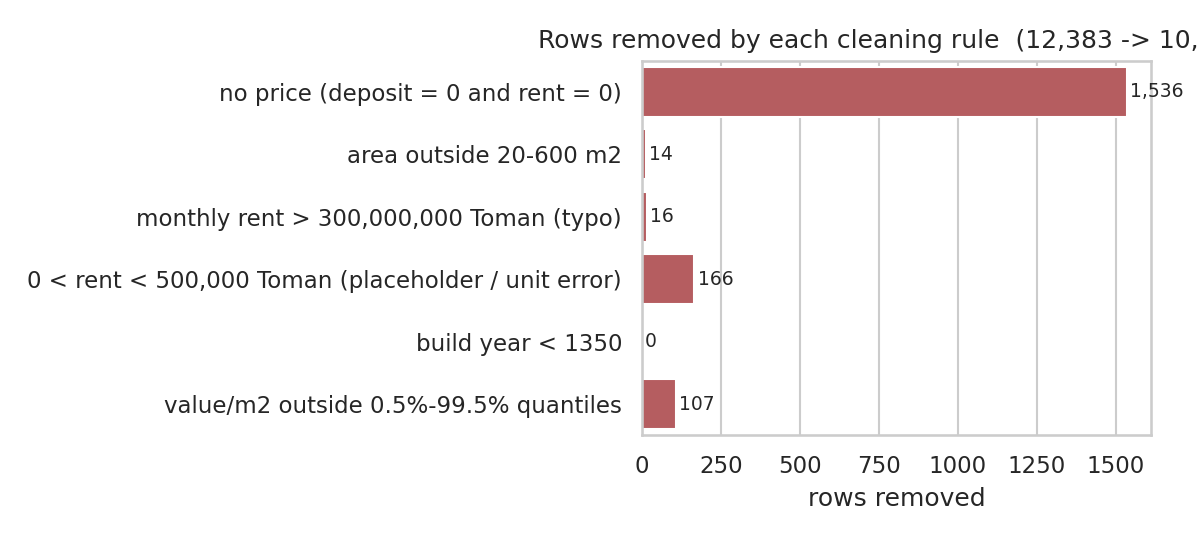

In [4]:
Image('../reports/figures/01_cleaning_rules.png')

## 2. The deposit + rent problem
Iranian rentals are quoted as a lump-sum **deposit** plus optional **monthly rent**. 37% of listings are *full deposit* (rent = 0). To compare listings we convert to a deposit-equivalent: `deposit + 30 x rent`. The source column `total_value` turns out to be almost identical to `deposit` (rent enters with weight 0.03), so it is ignored.

In [5]:
print(((raw['total_value'] - raw['deposit']).abs() / raw['deposit'].replace(0, np.nan)).describe())
df['full_deposit'].mean()

count   10,819.0
mean         0.3
std         16.4
min          0.0
25%          0.0
50%          0.0
75%          0.0
max      1,075.0
dtype: float64


np.float64(0.3754742033383915)

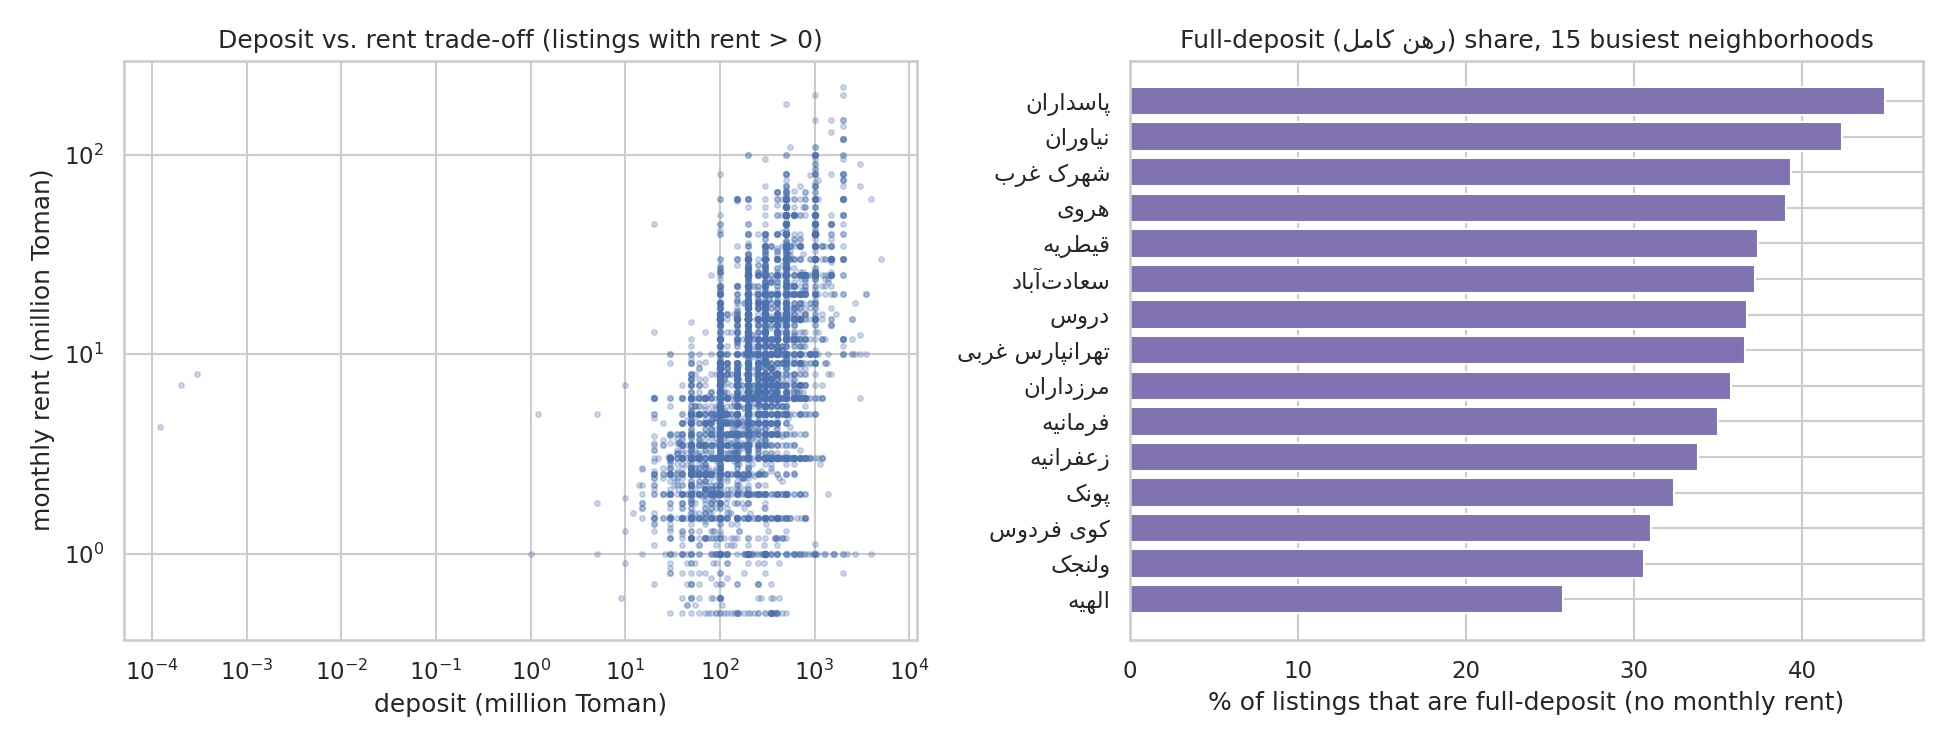

In [6]:
Image('../reports/figures/04_deposit_vs_rent.png')

## 3. Where is it expensive?

In [7]:
rk = pd.read_csv('../reports/neighborhood_ranking.csv')
rk.head(10)

,neighborhood,n,median_value_m,median_value_per_m2,median_area,full_deposit_share
0,الهیه,314,"1,615.0",8.9,195.0,0.3
1,کامرانیه,78,"1,350.0",8.6,170.0,0.3
2,زعفرانیه,290,"1,705.0",8.3,200.0,0.3
3,ولنجک,255,"1,100.0",7.8,145.0,0.3
4,فرمانیه,320,"1,400.0",7.6,200.0,0.3
5,محمودیه,50,"1,255.0",7.5,160.0,0.3
6,نیاوران,420,"1,200.0",7.5,160.0,0.4
7,دزاشیب,37,850.0,7.4,130.0,0.6
8,اقدسیه,131,"1,150.0",7.1,175.0,0.3
9,دروس,177,"1,300.0",7.0,175.0,0.4


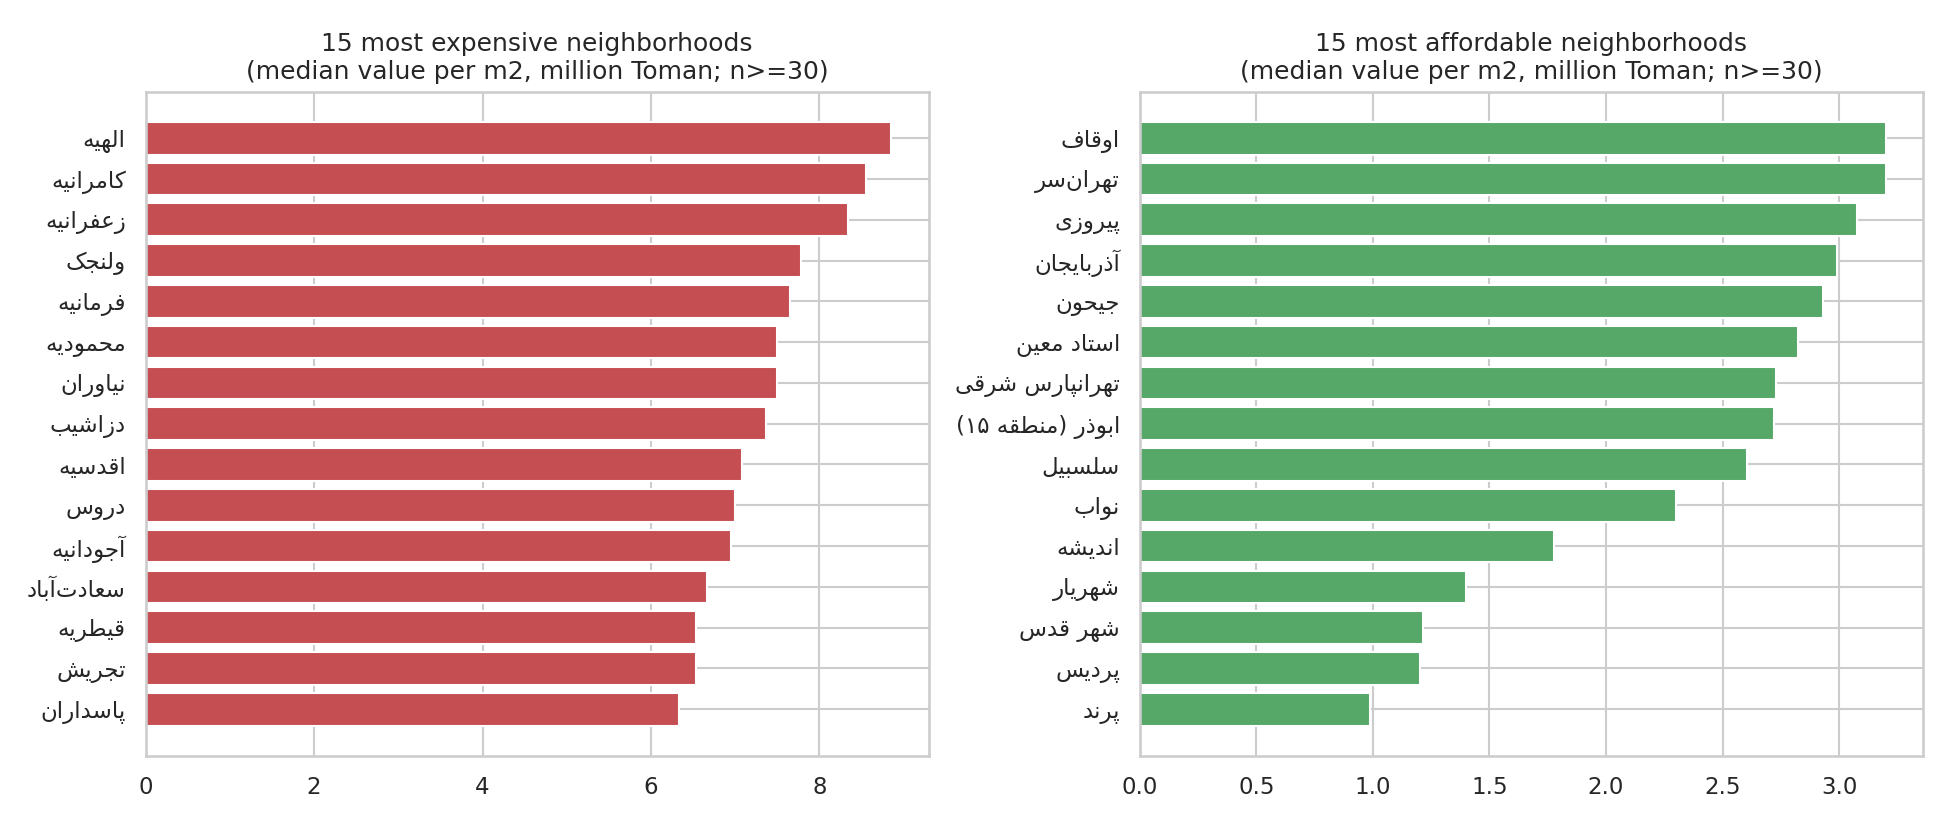

In [8]:
Image('../reports/figures/03_neighborhood_ranking.png')

The most expensive neighborhoods (Elahiyeh, Kamraniyeh, Zafaraniyeh...) cost ~9x more per m² than the cheapest satellite cities.

## 4. Do elevators and parking really add +80-100%?
Raw medians say yes, but amenities cluster in expensive, newer buildings. Comparing each listing to its **own neighborhood's** median shrinks the premium to roughly +21-28%. A textbook case of confounding.

{"elevator": 79.7, "parking": 99.2} {"elevator": 28.1, "parking": 21.3}


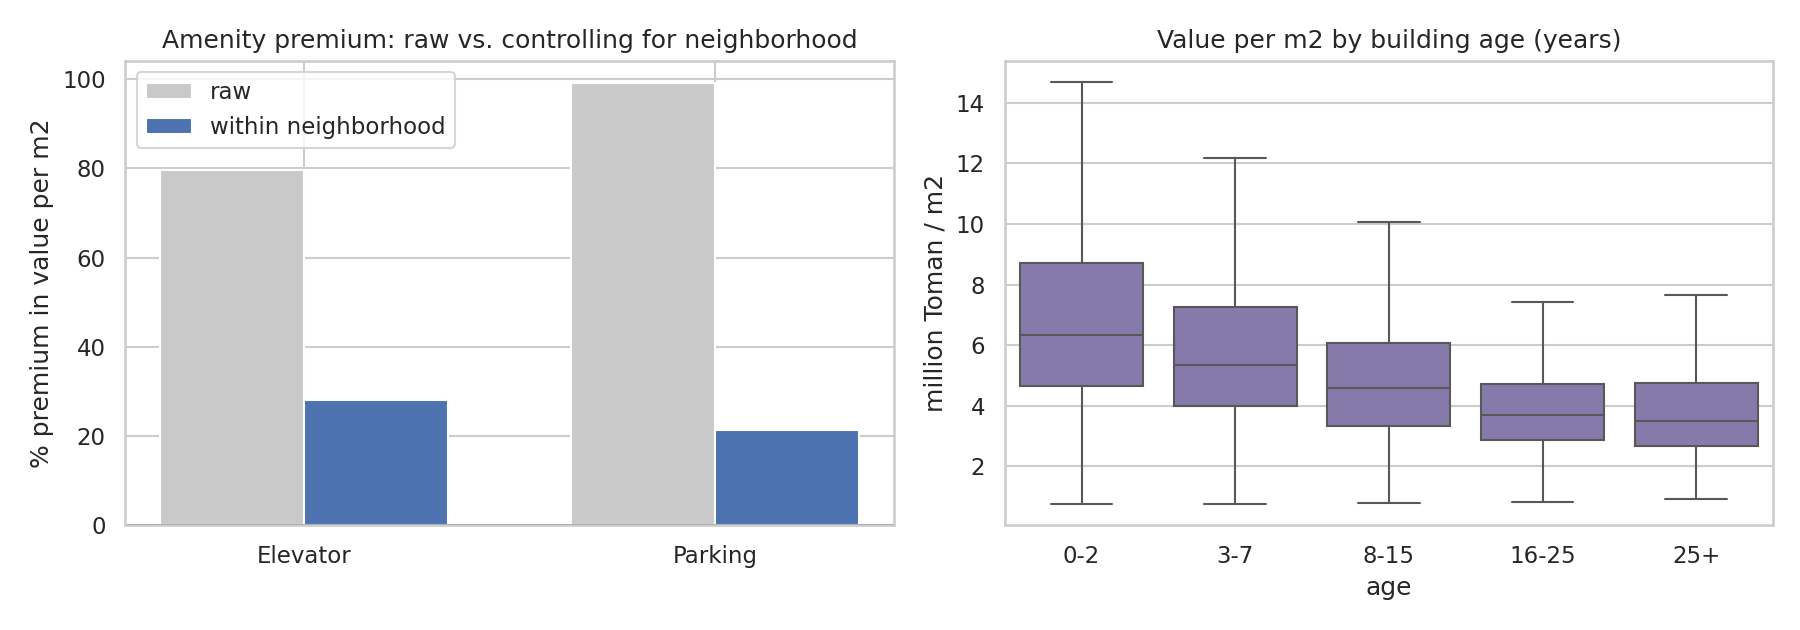

In [9]:
print(json.dumps(json.load(open('../reports/eda_stats.json'))['premium_raw_pct']), json.dumps(json.load(open('../reports/eda_stats.json'))['premium_within_neighborhood_pct']))
Image('../reports/figures/05_amenities_and_age.png')

## 5. Modelling
Target: `log(1 + deposit-equivalent in million Toman)`. Neighborhood (311 levels) is target-encoded *inside* cross-validation to avoid leakage. Three models, 5-fold CV, then one look at the hold-out set.

In [10]:
pd.read_csv('../reports/model_comparison.csv')

,model,r2_log,mae_million_toman,median_ape_pct,within_20pct,within_30pct
0,random_forest,0.9,158.8,15.8,0.6,0.8
1,xgboost,0.9,159.5,16.1,0.6,0.8
2,ridge,0.9,177.5,18.1,0.6,0.8


{
  "best_model": "random_forest",
  "test": {
    "r2_log": 0.9099,
    "mae_million_toman": 147.2,
    "median_ape_pct": 14.9,
    "within_20pct": 0.625,
    "within_30pct": 0.803
  },
  "interval_80_test_coverage": 0.81
}


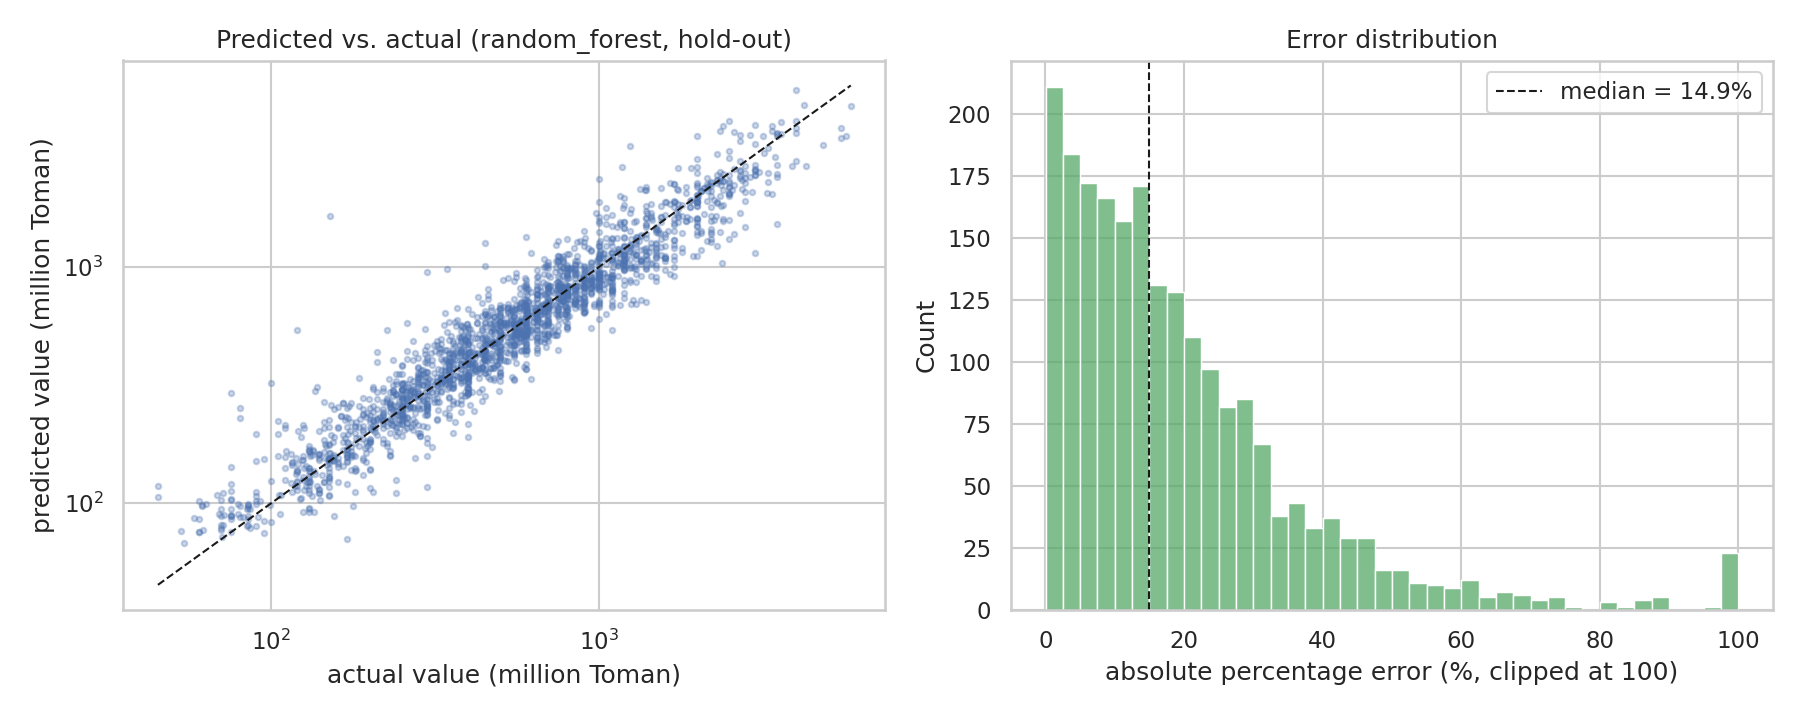

In [11]:
print(open('../reports/metrics.json').read())
Image('../reports/figures/06_model_evaluation.png')

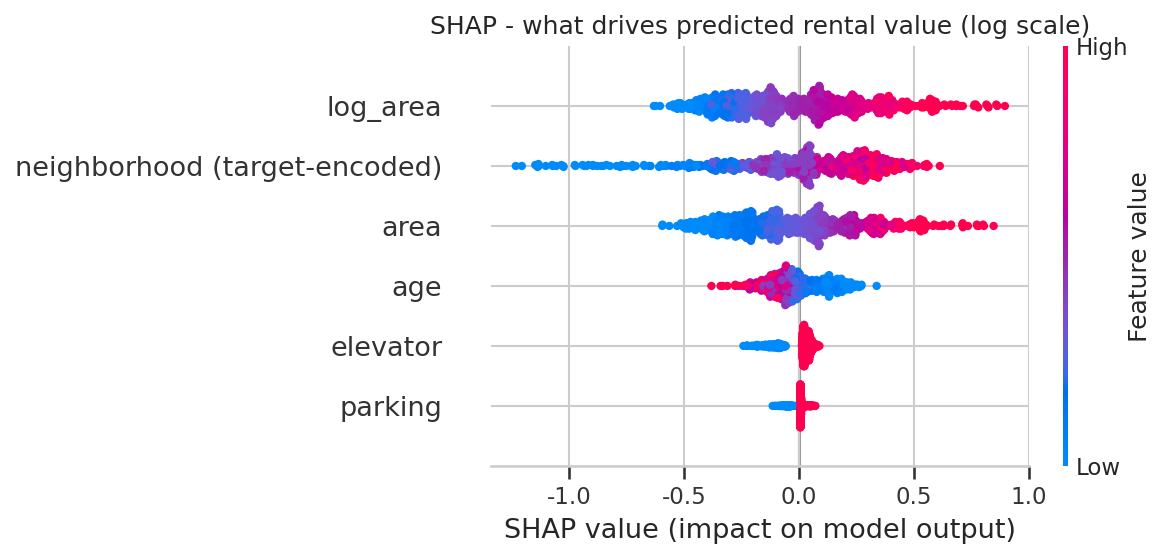

In [12]:
Image('../reports/figures/08_shap_summary.png')

## 6. Robustness to the conversion constant
Relative accuracy is *not* comparable across rows of this table (the target itself changes), but the neighborhood ranking is stable (Spearman >= 0.95).

In [13]:
pd.read_csv('../reports/sensitivity.csv')

,rent_to_deposit,neighborhood_rank_spearman_vs_30,r2_log,mae_million_toman,median_ape_pct,within_20pct,within_30pct
0,10,0.9,0.8,209.7,29.7,0.3,0.5
1,30,1.0,0.9,147.2,14.9,0.6,0.8
2,50,1.0,0.9,163.1,12.4,0.7,0.8
3,100,0.9,0.8,386.0,24.4,0.4,0.6
